
# TP 14: Predicting dynamics with Neural-ODE

**The goal of this pratical is use machine learning models to predict the
evolution of dynamical systems driven by physical laws, *e.g.* ordinary
Differential Equations (ODE).**

Let us considers a physcial system in Newtonian mechanichs composed of a
**damped pendulum**, with length $l$ and mass $m$, and $\theta$ being the
angle with respect to the vertical direction:

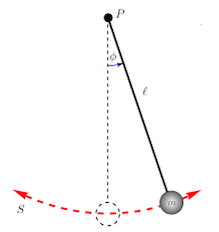

**Let us denote $\dot{\theta_t}:=\frac{d\theta}{dt}$ and
$\ddot{\theta}_t:=\frac{d^2\theta}{dt^2}$ as the first and second temporal
derivatives of $\theta$.** The dynamics of the pendulum is driven by the
following ODE on $\theta$:

\begin{equation} \ddot{\theta_t} + \omega_0^2~ sin\left(\theta_t\right) +
\alpha \dot{\theta}_t = 0 \end{equation}

where $\omega_0 = \sqrt{\frac{g}{\ell}}$ ($g$ is the gravitational constant, i.e. $9.8 ms^{-2}$), $\ell$ is the length of the rod,
and $\alpha = \frac{k}{ml^2}$ is the friction coefficient.

In the general case, the ODE does not have a closed-form
solution. Let us denote as $\mathbf{Y}_t=(\theta_t, \dot{\theta}_t)$ the 2d
state vector of the pendulum.

<br>----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


**<u>Question 1:</u> show that
 $\dot{\mathbf{Y}_t}=f\left({\mathbf{Y}_t}\right)$, *i.e* that the evolution
 of $\mathbf{Y}$ follows a first-order ODE. Give the expression of f.**

$\mathbf{Y}_t=(\theta_t, \dot{\theta}_t)$ is the 2d state vector of the pendulum, so the evolution of Y is $\dot{\mathbf{Y}_t}=(\dot{\theta}_t, \ddot{\theta}_t)$. 

<br><br> We have the dynamics of the pendulum driven by: 

\begin{equation} \ddot{\theta_t} + \omega_0^2~ sin\left(\theta_t\right) +
\alpha \dot{\theta}_t = 0 \end{equation} 

We can rewrite as: 

\begin{equation} \ddot{\theta_t} = - \omega_0^2~ sin\left(\theta_t\right) -
\alpha \dot{\theta}_t \end{equation} 

Which means $\dot{\mathbf{Y}_t}=(\dot{\theta}_t, - \omega_0^2~ sin\left(\theta_t\right) -
\alpha \dot{\theta}_t)$, so Y follows a first-order ODE since $\dot{\mathbf{Y}_t}$ only depends on ${\mathbf{Y}_t}$, with f($\dot{\mathbf{Y}_t}$) = (${\mathbf{Y}_t[1]}, - \omega_0^2~ sin\left({\mathbf{Y}_t[0]}\right) -
\alpha {\mathbf{Y}_t[1]})$). 

<br>----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


From a given initial condition $\mathbf{Y}_0=(\theta_0, \dot{\theta}_0)$, we
can estimate the state vector $\mathbf{Y}_t$ at any time $t$:

\begin{equation} \mathbf{Y}_t = \mathbf{Y}_0 + \int_0^t \dot{\mathbf{Y}_t} ~dt
= \mathbf{Y}_0 + \int_0^t f\left(\mathbf{Y}_t\right) dt
\end{equation}

where $f\left( \mathbf{Y}_t \right)$ only depends on the current state
$\mathbf{Y}_t$ at time $t$. The integral can be approximated
with numerical schemes. The Euler method is simplest one (see figure below):
starting from $\mathbf{Y}_0$, we have $\mathbf{Y}_{t+1} = \mathbf{Y}_{t} +
f\left(\mathbf{Y}_t\right)$ $\forall t>1$. There has been extensive studies for
developing improved numerical solvers in the last centuries, e.g. different
orders of Runge-Kutta solvers.

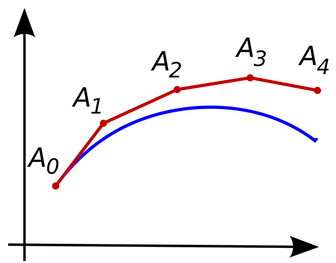


## Required Packages

Before starting, please ensure you have the following packages installed:

**Core packages:**
- `torch` (>=1.12) - PyTorch for deep learning
- `torchdiffeq` - ODE solvers for PyTorch (install with: `pip install torchdiffeq`)
- `scipy` - Scientific computing library (for `solve_ivp`)
- `numpy` - Numerical computing
- `matplotlib` - Plotting and visualization

**Installation commands:**
- **Conda:** `conda install pytorch scipy numpy matplotlib -c pytorch && pip install torchdiffeq`
- **Pip:** `pip install torch torchdiffeq scipy numpy matplotlib`

In [ ]:
# For Google Colab users: Run this cell to install required packages
!pip install torch torchdiffeq scipy numpy matplotlib


## Part I. Generating damped pendulum simulations
First, lets do some import

In [2]:
import math
import os

# Fix OpenMP library conflict on macOS (common issue with PyTorch)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
from scipy.integrate import solve_ivp

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from torch import optim

from torchdiffeq import odeint_adjoint, odeint  # odeint_adjoint used in commented line for students

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [20, 10]

# Device selection: prefer MPS (Apple Silicon) > CUDA > CPU
# Note: MPS can be unstable in some environments, use CPU if issues occur
try:
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
except Exception as e:
    # Fallback to CPU if device selection fails
    print(f"Warning: Device selection failed ({e}), using CPU")
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [3]:

import os

if os.environ.get("TESTING_MODE", "off") == "ON":
    # Reduce parameters for faster testing
    num_seq = 5
    time_horizon = 10
    n_hidden = 50
    n_epochs = 10
    plt.show = lambda *args, **kwargs: None

### I.a) DampedPendulum

**We will write a DampedPendulum Dataset, which simulates different pendulum trajectories from differents initial conditions. Fill the code in the code in the following DampedPendulum class. We use the following setting:** $\omega_0= \frac{\Pi}{3}$, $\alpha= 0.2$ , with $dt=0.5$

You have to fill the `__init__` and `_compute_trajectory` functions. For `_compute_trajectory`, the goal is to simulate a given trajectory from an initial condition:
- The function `_get_initial_condition` is provided
- To perform the simulation in `_compute_trajectory`, you need to:
    - Call the `_get_initial_condition`
    - Call the solver: we will use the solve_ivp method from from `scipy.integrate`, using the 'DOP853' method (Explicit Runge-Kutta method of order 8).
- Since the simulation is computationally demanding, the class below uses a cache to store each trajectory

In [82]:
class DampedPendulum(Dataset):
    def __init__(self, num_seq: int, time_horizon: int, dt: float):
        """Creates a new dataset of trajectories

        :param num_seq: Size of the dataset
        :param time_horizon: _description_
        :param dt: _description_
        """
        super().__init__()

        # À compléter...  
        self.omega0_square= (math.pi / 3)**2 # FILL WITH YOUR CODE
        self.alpha = 0.2 # FILL WITH YOUR CODE
        self.len = num_seq # NUMBER OF SEQUENCES IN DATASET - FILL WITH YOUR CODE
        self.time_horizon = time_horizon # FILL WITH YOUR CODE

        # This caches the trajectories so we compute them once only
        self.data = [None] * num_seq

        self.t_eval = torch.arange(0, self.time_horizon, float(dt))

    def __getitem__(self, index: int):
        if self.data[index] is None:
            self.data[index] = torch.tensor(self._compute_trajectory(), dtype=torch.float32)
        return {"states": self.data[index], "t": self.t_eval}

    def __len__(self):
        return len(self.data)

    def _get_initial_condition(self):
        """Returns the vector of initial conditions"""
        y0 = np.random.randn(2) * 2.0 - 1
        r = np.random.rand() + 1.3
        y0 = y0 / np.sqrt((y0**2).sum()) * r

        return y0

    def _get__state_derivative(self, t, x):  # coords = [q,p]
        # À compléter...  
        # using the f formula we found in Question 1:

        theta = x[0]
        theta_dot = x[1]

        theta_ddot = -self.omega0_square * np.sin(theta) - self.alpha * theta_dot

        return np.array([theta_dot, theta_ddot])

    def _compute_trajectory(self):
        # À compléter... # 
        y0 = self._get_initial_condition()
        
        states = solve_ivp(
            fun = self._get__state_derivative,
            t_span = [0, self.time_horizon],
            y0 = y0, 
            method = 'DOP853', 
            t_eval = self.t_eval
        )

        states = states.y.T
        states = np.transpose(states, (1, 0)) 
        
        return states


### I.b) Train/test data generation

**We can now define train and test dataloader** (use 25 train/test sequences
with a batch size of 25). **Plot the resulting trajectories ($\theta$ and
optionally $\dot{\theta}$).**

In [83]:
# path = "./exp2/pendulum/pendulum"

# Default parameters (can be overridden by TESTING_MODE)
if 'num_seq' not in locals():
    num_seq = 25
if 'time_horizon' not in locals():
    time_horizon = 20
dt = 0.5
dataset_train = DampedPendulum(num_seq, time_horizon, dt)
dataset_test = DampedPendulum(num_seq, time_horizon, dt)


batch_size = 25

train_loader = DataLoader(    
    dataset=dataset_train,
    batch_size=batch_size,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
    shuffle=True,
)
test_loader = DataLoader( 
    dataset=dataset_test,
    batch_size=batch_size,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
    shuffle=False,
)

In [84]:
# Show one item of the dataset

dataset_train[0]

{'states': tensor([[-1.6258, -1.9974, -2.0951, -1.9561, -1.5852, -0.9948, -0.2530,  0.4792,
           1.0277,  1.3064,  1.3090,  1.0614,  0.6152,  0.0660, -0.4509, -0.8026,
          -0.9399, -0.8568, -0.5886, -0.2035,  0.1951,  0.5064,  0.6650,  0.6505,
           0.4823,  0.2120, -0.0858, -0.3337, -0.4743, -0.4852, -0.3757, -0.1832,
           0.0375,  0.2275,  0.3420,  0.3601,  0.2864,  0.1478, -0.0152, -0.1587],
         [-1.0523, -0.4520,  0.0494,  0.5094,  0.9683,  1.3713,  1.5391,  1.3270,
           0.8391,  0.2758, -0.2571, -0.7180, -1.0366, -1.1088, -0.9015, -0.5016,
          -0.0480,  0.3701,  0.6825,  0.8190,  0.7404,  0.4840,  0.1434, -0.1950,
          -0.4603, -0.5953, -0.5694, -0.4023, -0.1535,  0.1070,  0.3182,  0.4332,
           0.4289,  0.3160,  0.1351, -0.0613, -0.2240, -0.3165, -0.3204, -0.2422]]),
 't': tensor([ 0.0000,  0.5000,  1.0000,  1.5000,  2.0000,  2.5000,  3.0000,  3.5000,
          4.0000,  4.5000,  5.0000,  5.5000,  6.0000,  6.5000,  7.0000,  7.5000,

---------------------------------------First derivative of Theta for 25 sequences over 0 to 20 seconds---------------------------------------


<Figure size 2000x1000 with 0 Axes>

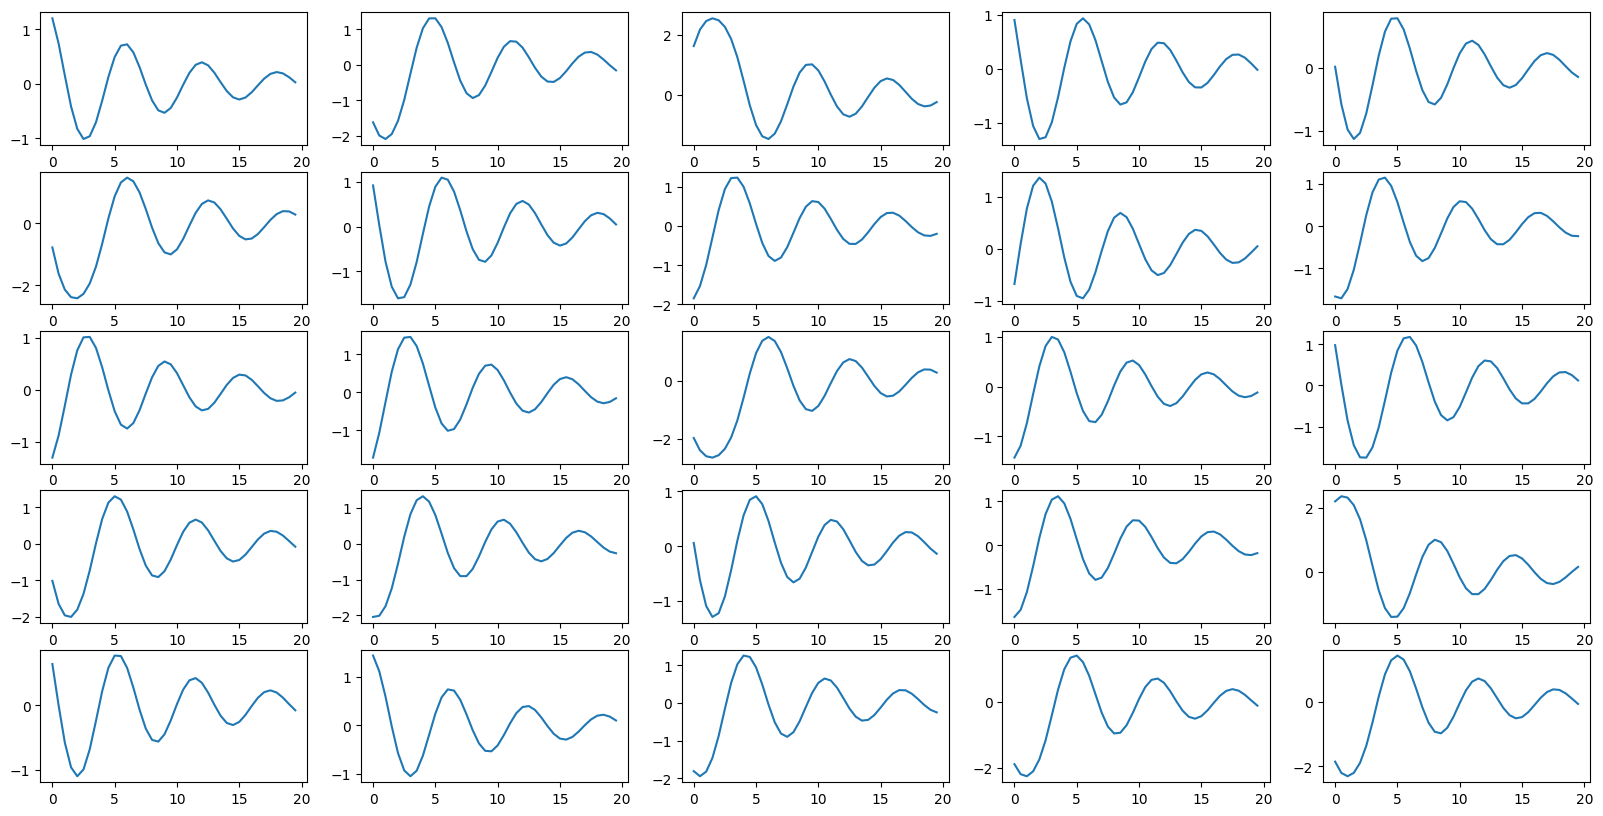

---------------------------------------Second derivative of Theta for 25 sequences over 0 to 20 seconds---------------------------------------


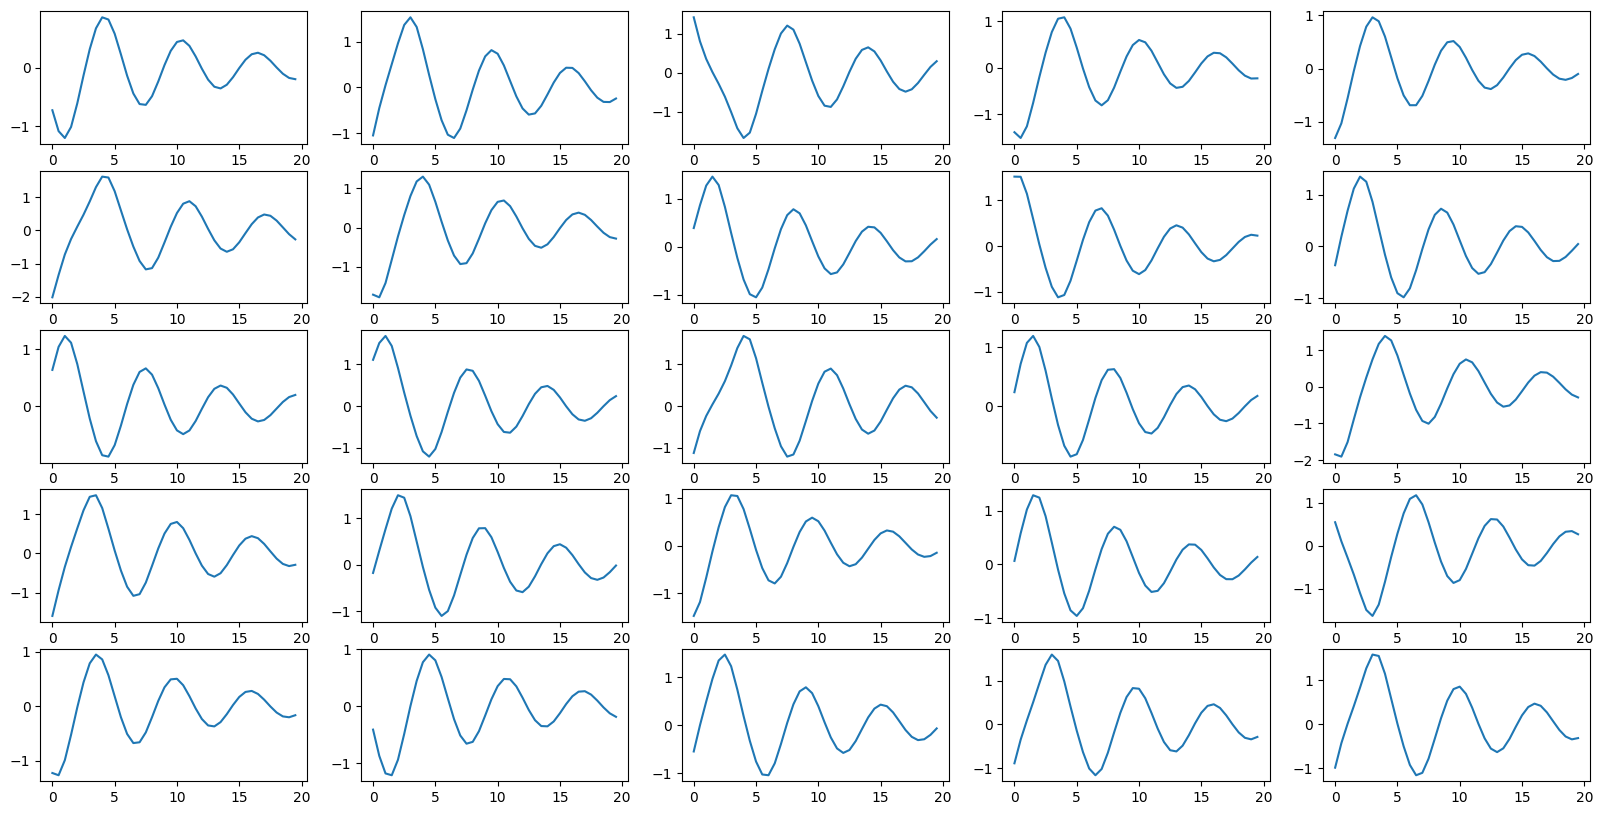

In [85]:
data = next(iter(train_loader))
draw_dottheta = True

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Determine grid size based on batch size
batch_size = data["states"].shape[0]
grid_size = min(int(np.ceil(np.sqrt(batch_size))), 5)
fig, axs = plt.subplots(grid_size, grid_size)

print(f"---------------------------------------First derivative of Theta for {num_seq} sequences over 0 to {time_horizon} seconds---------------------------------------")

for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(data["t"][idx], data["states"][idx, 0, :])
plt.show()


print(f"---------------------------------------Second derivative of Theta for {num_seq} sequences over 0 to {time_horizon} seconds---------------------------------------")


if draw_dottheta:
    fig, axs = plt.subplots(grid_size, grid_size)
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            if idx < batch_size:
                axs[i, j].plot(data["t"][idx], data["states"][idx, 1, :])

plt.show()

torch.Size([25, 40])
torch.Size([25, 2, 40])


<Figure size 2000x1000 with 0 Axes>

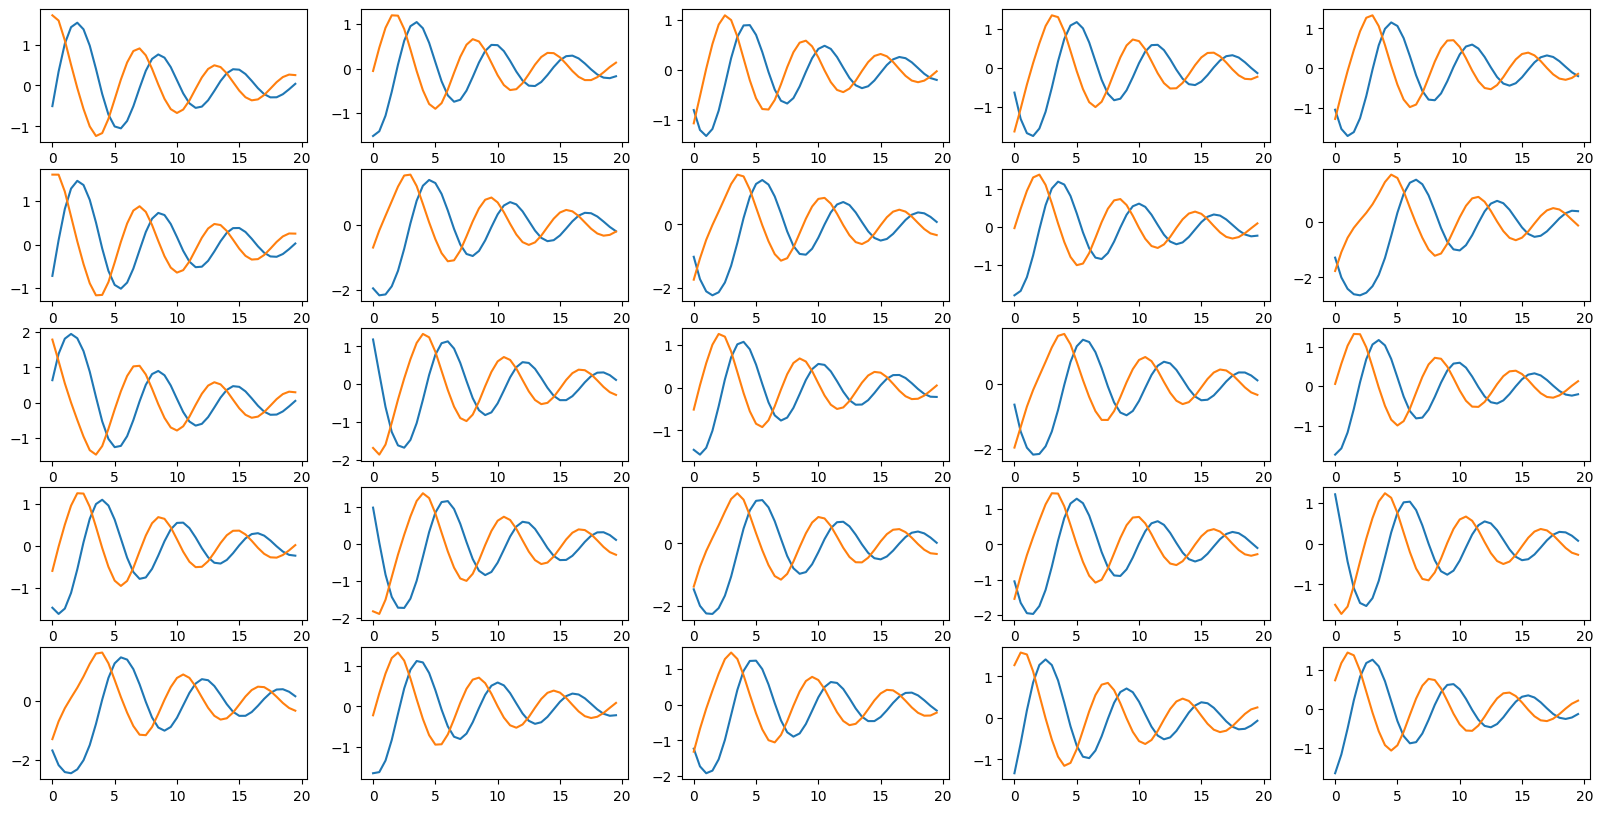

In [86]:
data_test = next(iter(test_loader))

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Determine grid size based on batch size
batch_size_test = data_test["states"].shape[0]
grid_size_test = min(int(np.ceil(np.sqrt(batch_size_test))), 5)
fig, axs = plt.subplots(grid_size_test, grid_size_test)
draw_dottheta = True

print(data_test["t"].shape)
print(data_test["states"].shape)

for i in range(grid_size_test):
    for j in range(grid_size_test):
        idx = i * grid_size_test + j
        if idx < batch_size_test:
            axs[i, j].plot(data_test["t"][idx], data_test["states"][idx, 0, :])

if draw_dottheta:
    for i in range(grid_size_test):
        for j in range(grid_size_test):
            idx = i * grid_size_test + j
            if idx < batch_size_test:
                axs[i, j].plot(
                    data_test["t"][idx], data_test["states"][idx, 1, :]
                )


### Plot initial condition distribution

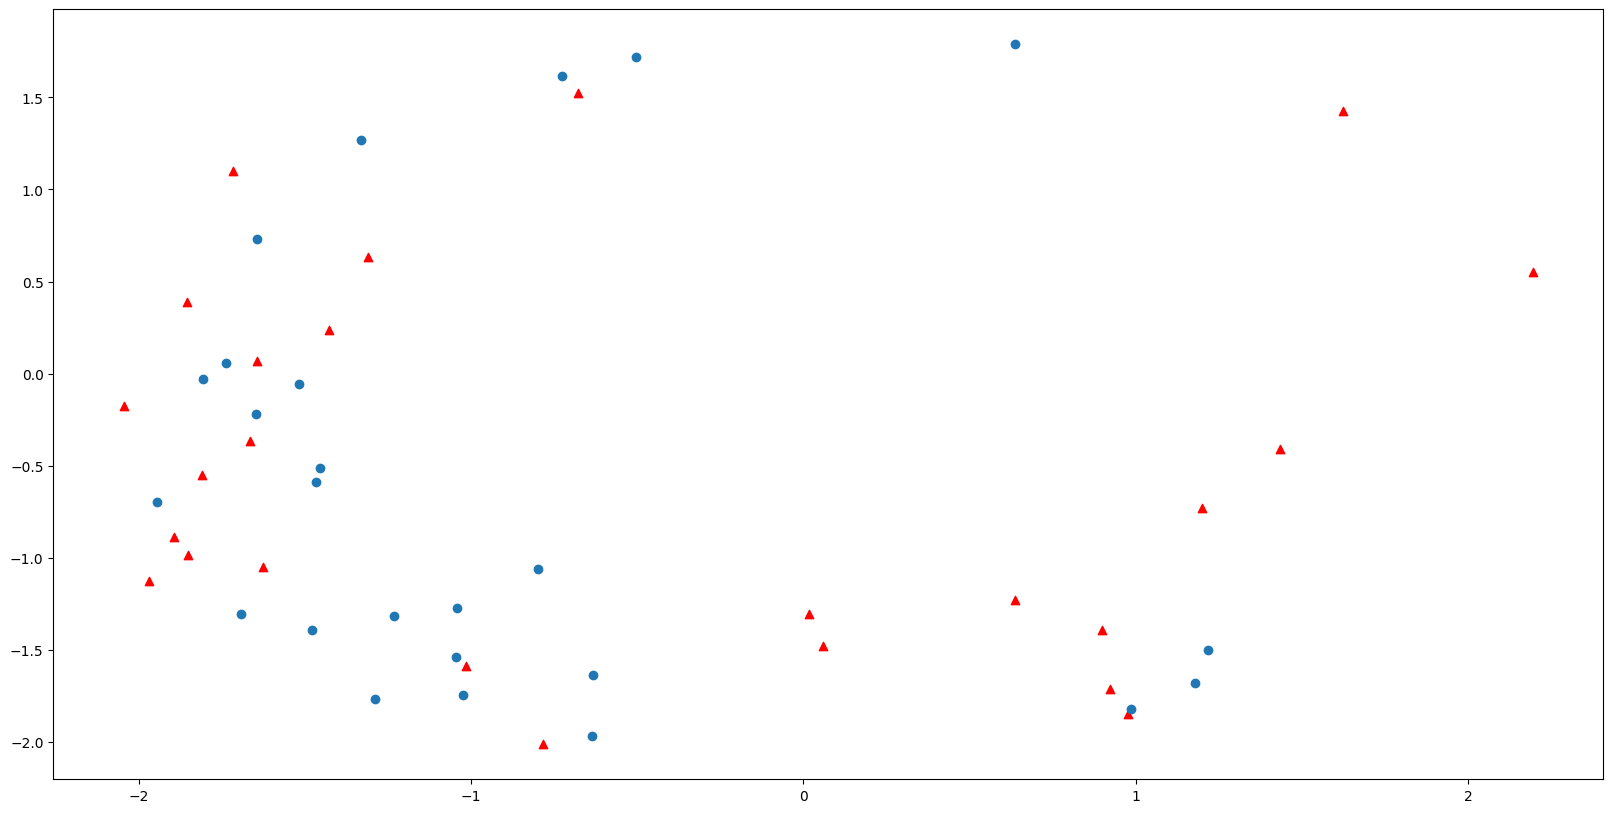

In [87]:
theta0_train = data["states"][:, 0, 0]
dtheta0_train = data["states"][:, 1, 0]

theta0_test = data_test["states"][:, 0, 0]
dtheta0_test = data_test["states"][:, 1, 0]

plt.figure()
plt.scatter(theta0_train, dtheta0_train, marker="^", c="r")
plt.scatter(theta0_test, dtheta0_test)


## 2) Predicting trajectories with Neural-ODE

The goal is to use the Neural-ODE method [1] to predict the future trajectory
from an initial condition. **More precisely, the idea is to define a
parametric model, *e.g.* an neural network, to predict the state's derivative
from the current state value:
$\dot{\mathbf{Y}_t}=f_{\theta}\left({\mathbf{Y}_t}\right)$, with $\theta$
being the neural net parameters. From an initial condition $\mathbf{Y}_0$ and
$f_{\theta}\left({\mathbf{Y}_t}\right)$, we can then use Equation below to
predict the full predicted trajectory $\hat{\mathbf{Y}}$. The goal is to
optimize $\theta$ parameters such that predicted trajectories are close to the
GT trajectories in the training set.**

\begin{equation} \hat{\mathbf{Y}_t}  = \mathbf{Y}_0 + \int_0^t
f_{\theta}\left(\mathbf{Y}_t\right) dt \end{equation}


**Let's fill the DerivativeEstimator class to predict the the state's
derivative.** We will use a simple MLP (2 hidden layers + ReLU) for prediction
since the state is a 2D vector.


In [107]:
# only returns estimated derivative

class DerivativeEstimator(nn.Module):
    def __init__(self, n_state: int, n_hidden: int):
        super().__init__()
        # À compléter...  
        self.mlp = nn.Sequential(
            nn.Linear(n_state, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_state)
        )

    def forward(self, t, state):
        # À compléter...  
        return self.mlp(state)



**The forecaster will perform the prediction from a initial state $y_0$**. To
perform the numerical integration, we use the [`odeint` method from
torchdiffeq](https://github.com/rtqichen/torchdiffeq). We will use the generic
'rk4' solver to perform numerical integration. **Fill the following Forecaster
class with:**
- A constructor creating a reference to an DerivativeEstimator instance
- the forward method calls the `odeint` method to perform integration from an
  initial $y_0$ state. **N.B.**: the output dimensions after calling `odeint`
  will be `T x batch_size x n_c`, swap them to fit the requested Pytorch
  standard (`batch_size x n_c X T`)

In [108]:
# predicts Yt by integrating DerivativeEstimator output

class Forecaster(nn.Module):
    def __init__(self, n_state, n_hidden, method="rk4"):
        super().__init__()

        # À compléter...  
        self.derivative = DerivativeEstimator(n_state, n_hidden)
        self.method = method

    def forward(self, y0: torch.Tensor, t: torch.LongTensor):
        """Computes the y_t prediction at times t
        given the initial state y0 of size (B x N_c).

        Returns a tensor of shape (B x N_c x T)
        """
        # À compléter...  
        integral = odeint(self.derivative, y0, t, method = self.method)

        # [T x batch_size x n_c] -> [batch_size x n_c X T]
        integral = integral.permute(1, 2, 0)

        return integral


### Write the training loop!

For each batch:
- Get the first state of each training trajectory
- Perform prediction of the forecaster for each time step of the horizon
- We will use a simple MSE loss between the ground truth and predicted
  trajectories.
- Use an Adam optimizer (default paramters)
- Plot the train / test trajectories

In [ ]:
n_state = 2
# Default parameters (can be overridden by TESTING_MODE)
if 'n_hidden' not in locals():
    n_hidden = 200
if 'n_epochs' not in locals():
    n_epochs = 1001
# tau_1 = 1e-3

forecaster_net = Forecaster(n_state, n_hidden)
forecaster_net = forecaster_net.to(device)
optimizer = optim.Adam(forecaster_net.parameters(), lr=1e-3)
traj_loss = nn.MSELoss()

epoch_loss = 0
losses = []

for e in range(n_epochs):
    # À compléter...  
    for i, data in enumerate(train_loader):

        states = data["states"].to(device)
        t = data["t"][0].to(device)
        #print(t.shape)
        
        # Get the first state of each training trajectory
        y0 = states[ : , :, 0]
        #print(y0.shape)
        
        # Perform prediction of the forecaster for each time step of the horizon
        GT_traj = states
        traj_pred = forecaster_net(y0, t)
        #print(GT_traj.shape)
        #print(traj_pred.shape)
        
        # We will use a simple MSE loss between the ground truth and predicted trajectories.
        loss = traj_loss(traj_pred, GT_traj)
        
        # Use an Adam optimizer (default paramters)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    if e % 100 == 0:
        print(f"Epoch {e}, loss = {epoch_loss:.4f}")

Epoch 0, loss = 2.0037
Epoch 100, loss = 17.3351
Epoch 200, loss = 18.5513
Epoch 300, loss = 18.6411


<Figure size 2000x1000 with 0 Axes>

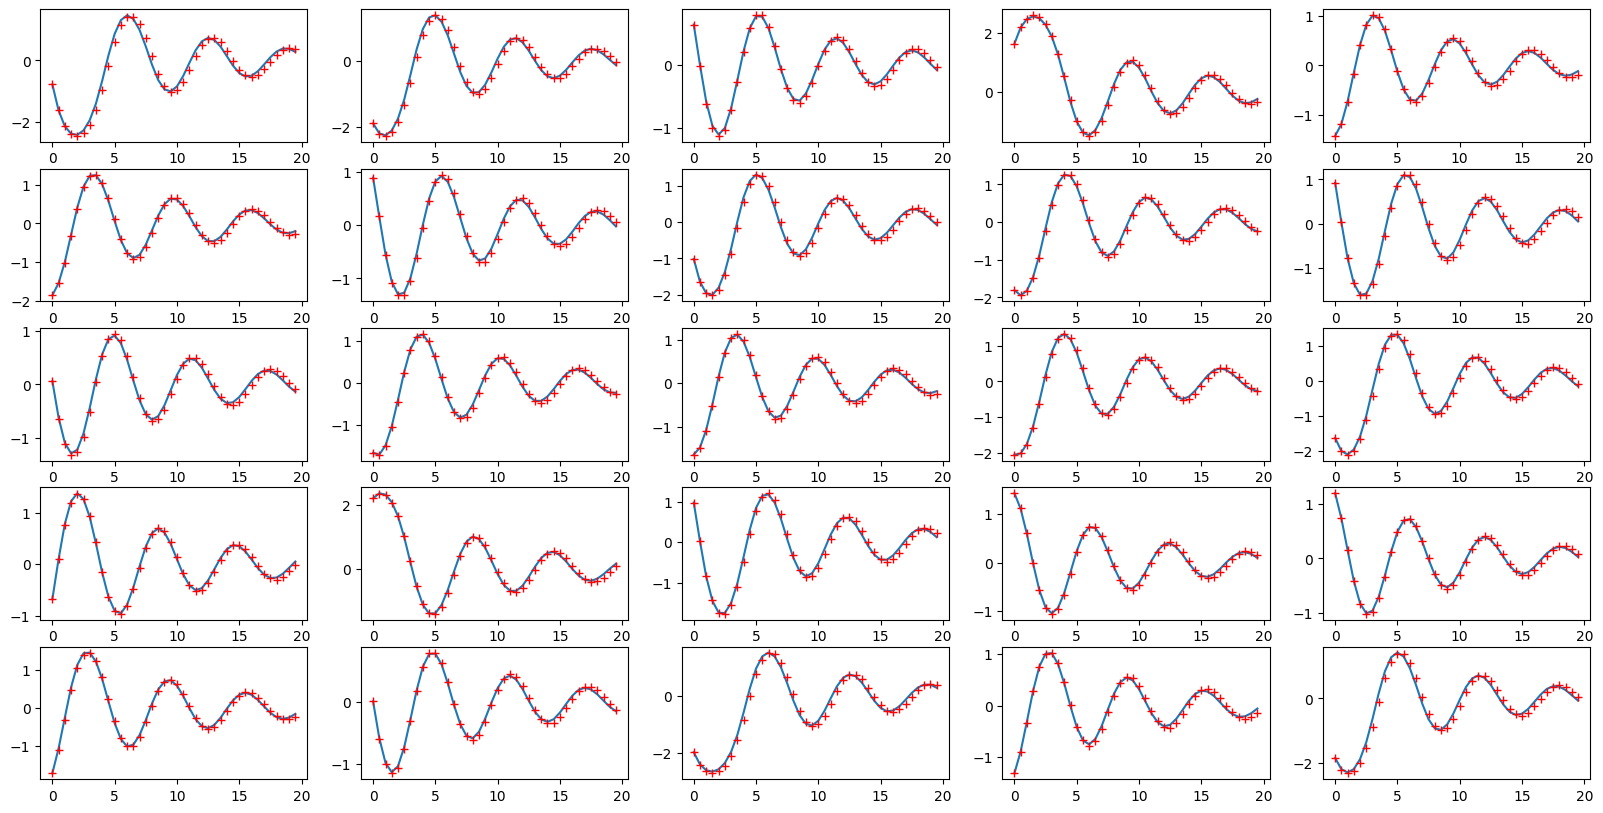

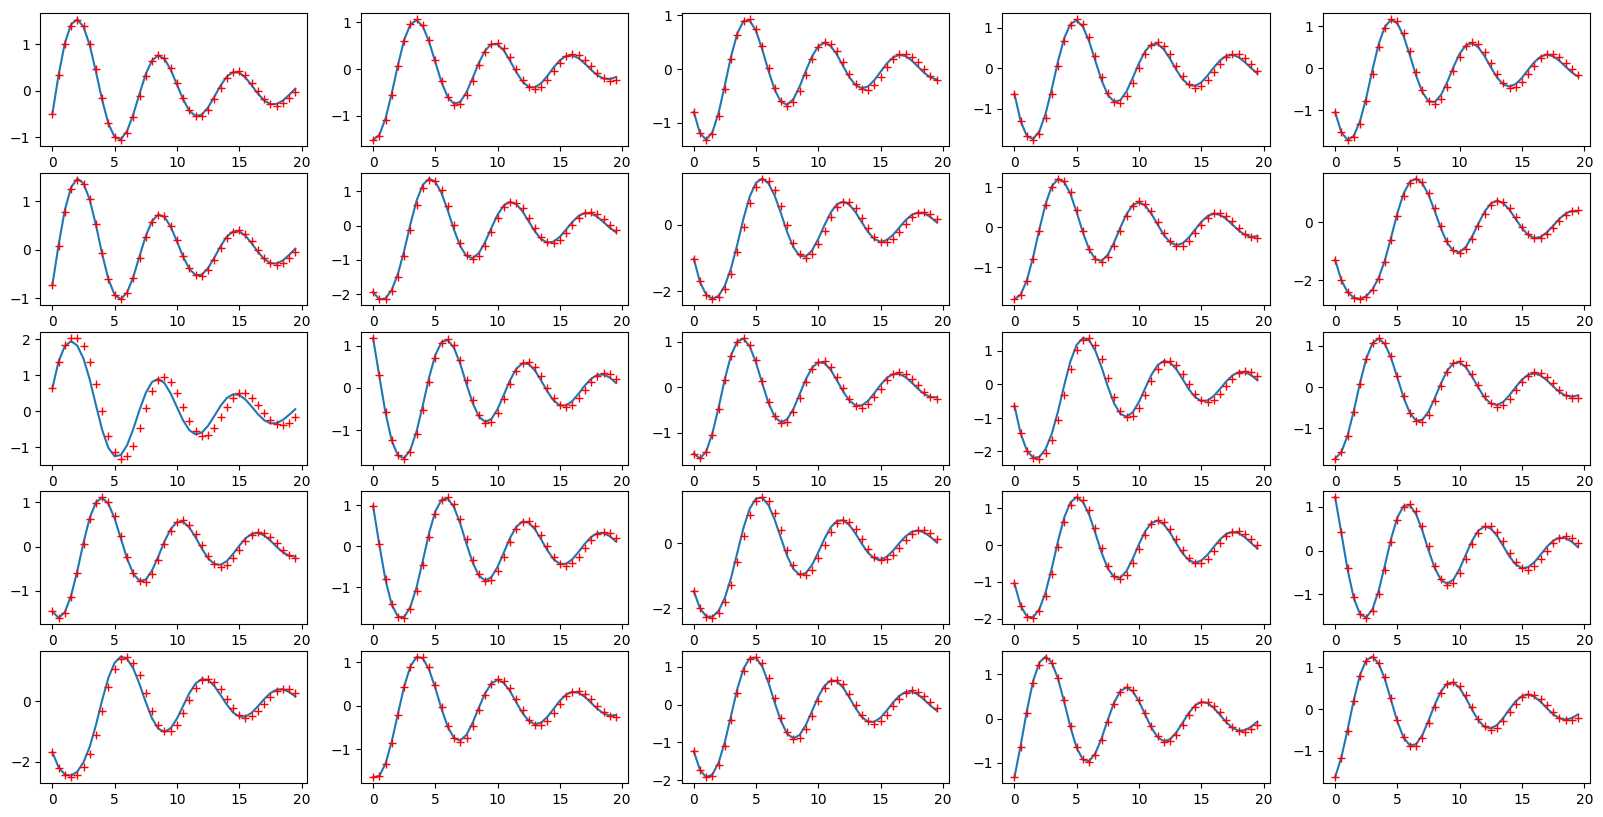

In [117]:
# The code below plots the predicted values

## # pred contains
## pred = ...

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Get batch data for plotting (re-fetch if needed for device compatibility)
plot_batch = next(iter(train_loader))
plot_batch_test = next(iter(test_loader))

# Get predictions for plotting
with torch.no_grad():
    y0_plot = plot_batch["states"][:, :, 0].to(device)
    t_plot = plot_batch["t"][0].to(device)
    pred_plot = forecaster_net(y0_plot, t_plot)
    
    y0_plot_test = plot_batch_test["states"][:, :, 0].to(device)
    t_plot_test = plot_batch_test["t"][0].to(device)
    pred_plot_test = forecaster_net(y0_plot_test, t_plot_test)

p = pred_plot.detach().cpu().numpy()
ptest = pred_plot_test.detach().cpu().numpy()

# Determine grid size based on batch size
batch_size = min(plot_batch["states"].shape[0], 25)
grid_size = int(np.ceil(np.sqrt(batch_size)))
if grid_size > 5:
    grid_size = 5

fig, axs = plt.subplots(grid_size, grid_size)
for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(
                plot_batch["t"][idx].cpu().numpy(),
                plot_batch["states"][idx, 0, :].cpu().numpy(),
                plot_batch["t"][idx].cpu().numpy(),
                p[idx, 0, :],
                "r+",
            )

fig, axs = plt.subplots(grid_size, grid_size)
for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(
                plot_batch_test["t"][idx].cpu().numpy(),
                plot_batch_test["states"][idx, 0, :].cpu().numpy(),
                plot_batch_test["t"][idx].cpu().numpy(),
                ptest[idx, 0, :],
                "r+",
            )


# Bonus: see [this paper](https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf) [1]
Experiment Neural ODE for other applications: 
- **Replacing residual networks with ODEs for supervised learning** (see section 3 in paper), using the adjoint method.
- **Application for irregularly-sampled time series** (see section 5 in the paper).


[1] **Neural Ordinary Differential Equations.**
Ricky T. Q. Chen, Yulia Rubanova, Jesse Bettencourt, David K. Duvenaud.
NeurIPS 2018.

<!--bibtex

@inproceedings{nODE-NEURIPS2018,
 author = {Chen, Ricky T. Q. and Rubanova, Yulia and Bettencourt, Jesse and Duvenaud, David K},
 booktitle = {Advances in Neural Information Processing Systems},
 editor = {S. Bengio and H. Wallach and H. Larochelle and K. Grauman and N. Cesa-Bianchi and R. Garnett},
 pages = {},
 publisher = {Curran Associates, Inc.},
 title = {Neural Ordinary Differential Equations},
 url = {https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf},
 volume = {31},
 year = {2018}
}

... Other Bibtex entries go here.

-->

<!--bibtex

@inproceedings{nODE-NEURIPS2018,
 author = {Chen, Ricky T. Q. and Rubanova, Yulia and Bettencourt, Jesse and Duvenaud, David K},
 booktitle = {Advances in Neural Information Processing Systems},
 editor = {S. Bengio and H. Wallach and H. Larochelle and K. Grauman and N. Cesa-Bianchi and R. Garnett},
 pages = {},
 publisher = {Curran Associates, Inc.},
 title = {Neural Ordinary Differential Equations},
 url = {https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf},
 volume = {31},
 year = {2018}
}

... Other Bibtex entries go here.

-->